In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
# importing catboost classifier
from catboost import CatBoostClassifier
# confusion matrix and classification report
from sklearn.metrics import confusion_matrix, classification_report

data = pd.read_csv("combined.csv")
data.head()

,job_title,job_location,job_salary,job_summary,is_AI,source
0,Data Science Manager,"Chicago, IL","$120,000 - $150,000 a year",Our client is hiring a Data Scientist to suppo...,1,chatgpt ai
1,AI Engineer,"Boston, MA","$120,000 - $150,000 a year",This role sits within a cross-functional analy...,1,chatgpt ai
2,Statistician - Behavioral Biology,"Silver Spring, MD 20910",NaN,Overview: About The Geneva Foundation ...,0,human
3,Data Science Lead,"Chicago, IL 60601",NaN,Pinnacle AI Labs is a world-class research and...,1,claude ai
4,Data Scientist,"Boston, MA 02124",NaN,The Opportunity MassMutual’s Advanced Analy...,0,human


In [21]:
X = data.drop(columns=["is_AI", "source"])
y = data["is_AI"]
# train test split 80 - 20

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=6)

0:	learn: 0.6265693	test: 0.6237703	best: 0.6237703 (0)	total: 8.46ms	remaining: 8.45s
100:	learn: 0.0728861	test: 0.0452092	best: 0.0452092 (100)	total: 261ms	remaining: 2.33s
200:	learn: 0.0541848	test: 0.0443712	best: 0.0442760 (157)	total: 530ms	remaining: 2.11s
300:	learn: 0.0452087	test: 0.0449262	best: 0.0441393 (213)	total: 801ms	remaining: 1.86s
400:	learn: 0.0391225	test: 0.0463848	best: 0.0441393 (213)	total: 1.1s	remaining: 1.65s
500:	learn: 0.0350245	test: 0.0475549	best: 0.0441393 (213)	total: 1.38s	remaining: 1.38s
600:	learn: 0.0321127	test: 0.0480955	best: 0.0441393 (213)	total: 1.63s	remaining: 1.08s
700:	learn: 0.0296146	test: 0.0487791	best: 0.0441393 (213)	total: 1.86s	remaining: 792ms
800:	learn: 0.0277249	test: 0.0499665	best: 0.0441393 (213)	total: 2.09s	remaining: 520ms
900:	learn: 0.0262219	test: 0.0502011	best: 0.0441393 (213)	total: 2.32s	remaining: 255ms
999:	learn: 0.0249413	test: 0.0508465	best: 0.0441393 (213)	total: 2.56s	remaining: 0us

bestTest = 0.04

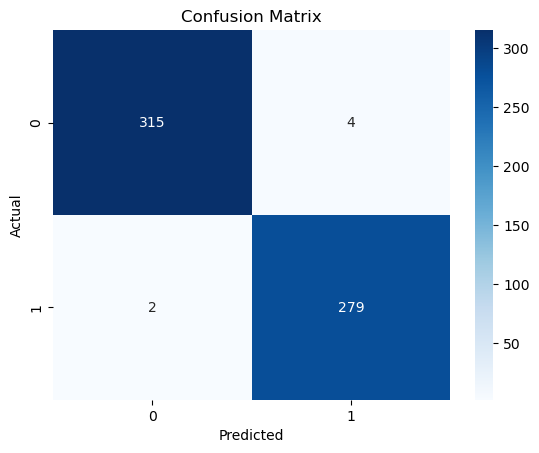

In [22]:
# catboost classifier to classify

cat_features = [col for col in X_train.columns if X_train[col].dtype == 'object']

# ensure proper type
for col in cat_features:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    loss_function='MultiClass',
    eval_metric='MultiClass',
    verbose=100
)

model.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_test, y_test))
# predictions
y_pred = model.predict(X_test)
# confusion matrix and classification report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
# showing cm using seaborn heatmap
import seaborn as sns
import matplotlib.pyplot as plt 
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [37]:
# testing the model on a single job posting
test_job = {
    "job_title": "Senior Data Scientist",
    "job_location": "New York",
    "job_salary": "",
    "job_summary": """We are a growing, innovation-focused company that leverages data science, machine learning, and modern software engineering practices to build trusted products and services used by millions of end users. Our organization is a well-established technology and analytics company that supports a wide range of commercial and public-sector clients. We emphasize rigorous data-driven decision making and invest heavily in scalable analytics platforms. This company operates at the intersection of advanced analytics, cloud computing, and applied research. Our teams partner closely with customers to translate complex problems into practical, data-backed solutions. Our organization is a well-established technology and analytics company that supports a wide range of commercial and public-sector clients. We emphasize rigorous data-driven decision making and invest heavily in scalable analytics platforms. This company operates at the intersection of advanced analytics, cloud computing, and applied research. Our teams partner closely with customers to translate complex problems into practical, data-backed solutions. We are a growing, innovation-focused company that leverages data science, machine learning, and modern software engineering practices to build trusted products and services used by millions of end users.

Responsibilities:
- Monitor model performance over time and apply retraining or recalibration strategies as needed. Monitor model performance over time and apply retraining or recalibration strategies as needed. Monitor model performance over time and apply retraining or recalibration strategies as needed.
- Develop feature engineering strategies and reusable data pipelines that support experimentation and model iteration. Develop feature engineering strategies and reusable data pipelines that support experimentation and model iteration.
- Design, develop, and deploy machine learning models that operate reliably in production environments. Design, develop, and deploy machine learning models that operate reliably in production environments.
- Document methodologies and communicate results through written reports, dashboards, and presentations. Document methodologies and communicate results through written reports, dashboards, and presentations.
- Explore, clean, and analyze large structured and unstructured datasets to identify trends, patterns, and opportunities. Explore, clean, and analyze large structured and unstructured datasets to identify trends, patterns, and opportunities.

Qualifications:
- Strong proficiency in Python and experience with common data science libraries such as pandas, NumPy, scikit-learn, PyTorch, or TensorFlow. Strong proficiency in Python and experience with common data science libraries such as pandas, NumPy, scikit-learn, PyTorch, or TensorFlow.
- Solid understanding of statistics, probability, model evaluation techniques, and experimental design. Solid understanding of statistics, probability, model evaluation techniques, and experimental design.
- Bachelor’s or Master’s degree in Data Science, Computer Science, Statistics, Mathematics, or a related quantitative field. Bachelor’s or Master’s degree in Data Science, Computer Science, Statistics, Mathematics, or a related quantitative field.
- Experience working with relational databases, SQL, and large-scale data platforms. Experience working with relational databases, SQL, and large-scale data platforms. Experience working with relational databases, SQL, and large-scale data platforms.
- At least 3–7 years of hands-on experience building and evaluating statistical or machine learning models. At least 3–7 years of hands-on experience building and evaluating statistical or machine learning models.

Preferred Qualifications:
- Experience deploying models into cloud-based environments such as AWS, GCP, or Azure. Experience deploying models into cloud-based environments such as AWS, GCP, or Azure. Experience deploying models into cloud-based environments such as AWS, GCP, or Azure.
- Exposure to natural language processing, time series forecasting, recommender systems, or computer vision. Exposure to natural language processing, time series forecasting, recommender systems, or computer vision.
- Familiarity with MLOps concepts, including versioning, monitoring, CI/CD pipelines, and model governance. Familiarity with MLOps concepts, including versioning, monitoring, CI/CD pipelines, and model governance.

This role offers the opportunity to work on meaningful, high-impact initiatives with significant ownership and visibility. Candidates should be comfortable operating in a collaborative, fast-paced environment where priorities may evolve over time. We offer competitive compensation, comprehensive benefits, and opportunities for professional growth and advancement. We offer competitive compensation, comprehensive benefits, and opportunities for professional growth and advancement. Candidates should be comfortable operating in a collaborative, fast-paced environment where priorities may evolve over time. This role offers the opportunity to work on meaningful, high-impact initiatives with significant ownership and visibility. This role o"""}   
test_df = pd.DataFrame([test_job])
model.predict(test_df)


array([[0]])